In [151]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

# Fase 1
### K-NN basico

In [152]:
df_train = pd.read_csv("train_df.csv")

df_test = pd.read_csv("test_df.csv")

df_val = pd.read_csv("val_df.csv")

x_train = df_train.drop(columns = ["target"])
y_train = df_train["target"]

x_test = df_test.drop(columns = ["target"])
y_test = df_test["target"]

x_val = df_val.drop(columns = ["target"])
y_val = df_val["target"]

melhor_k = 0
melhor_acc = 0
ks = range(1, 51, 2)
historico_acc = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred_val = knn.predict(x_val)
    acc = accuracy_score(y_val, y_pred_val)
    historico_acc.append(acc)
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print(f"\n>>> Melhor K selecionado: {melhor_k}")

# Treinar modelo final com o melhor_k
knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(x_train, y_train)

# Predição no teste para o relatório final 
y_pred_test = knn_final.predict(x_test)

# Métricas Obrigatórias: Acurácia, Precision, Recall e F-measure 
print("\n--- RELATÓRIO DE DESEMPENHO (TESTE) ---")
print(classification_report(y_test, y_pred_test))


>>> Melhor K selecionado: 3

--- RELATÓRIO DE DESEMPENHO (TESTE) ---
                              precision    recall  f1-score   support

                      Empate       0.83      0.97      0.89        30
                     O vence       0.80      0.93      0.86        30
Possibilidade de Fim de Jogo       0.57      0.13      0.22        30
                    Tem jogo       0.72      0.97      0.83        30
                     X vence       0.88      0.97      0.92        30

                    accuracy                           0.79       150
                   macro avg       0.76      0.79      0.74       150
                weighted avg       0.76      0.79      0.74       150



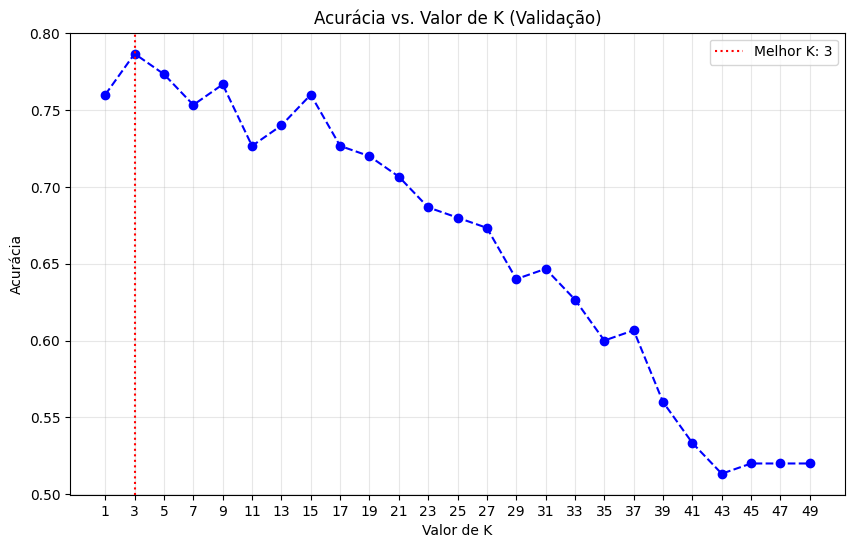

In [153]:
plt.figure(figsize=(10, 6))
plt.plot(ks, historico_acc, marker='o', linestyle='--', color='b')
plt.axvline(x=melhor_k, color='r', linestyle=':', label=f'Melhor K: {melhor_k}')

plt.title('Acurácia vs. Valor de K (Validação)')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.xticks(ks)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

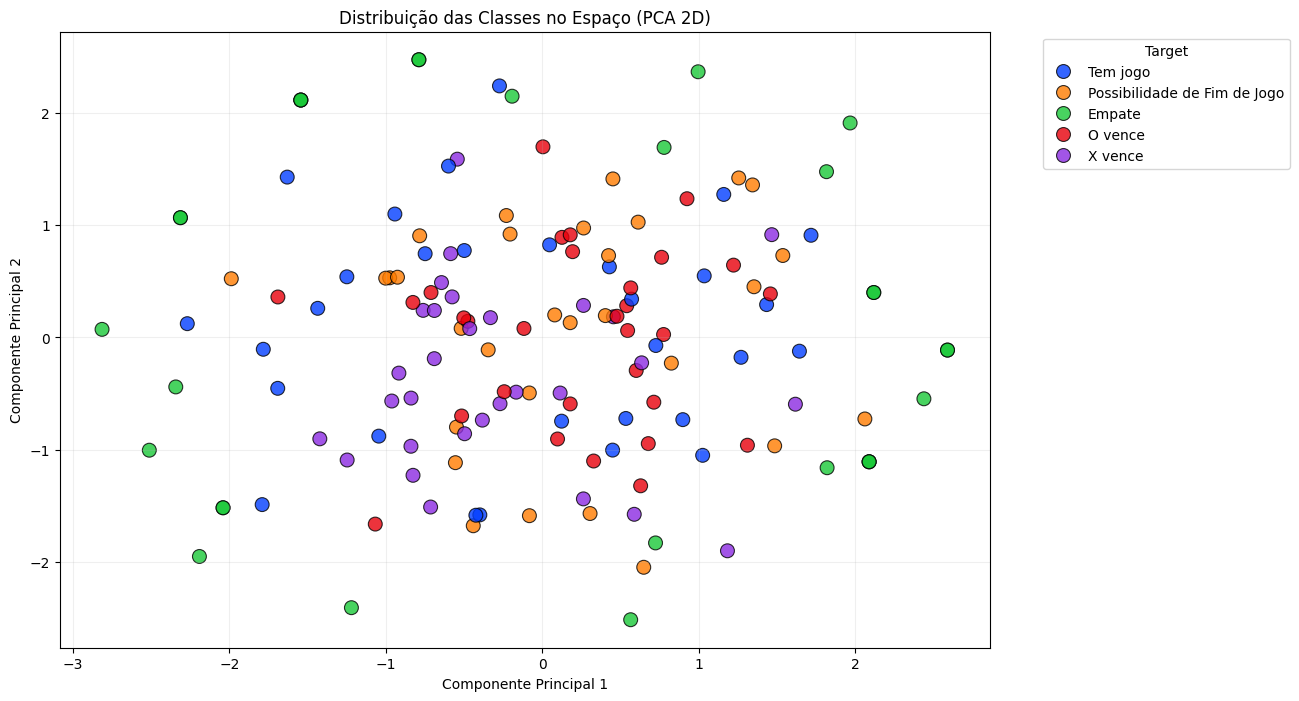

In [154]:
pca = PCA(n_components=2)
x_test_2d = pca.fit_transform(x_test)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=x_test_2d[:, 0], y=x_test_2d[:, 1], hue=y_test, 
                palette='bright', s=100, alpha=0.8, edgecolor='black')

plt.title('Distribuição das Classes no Espaço (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

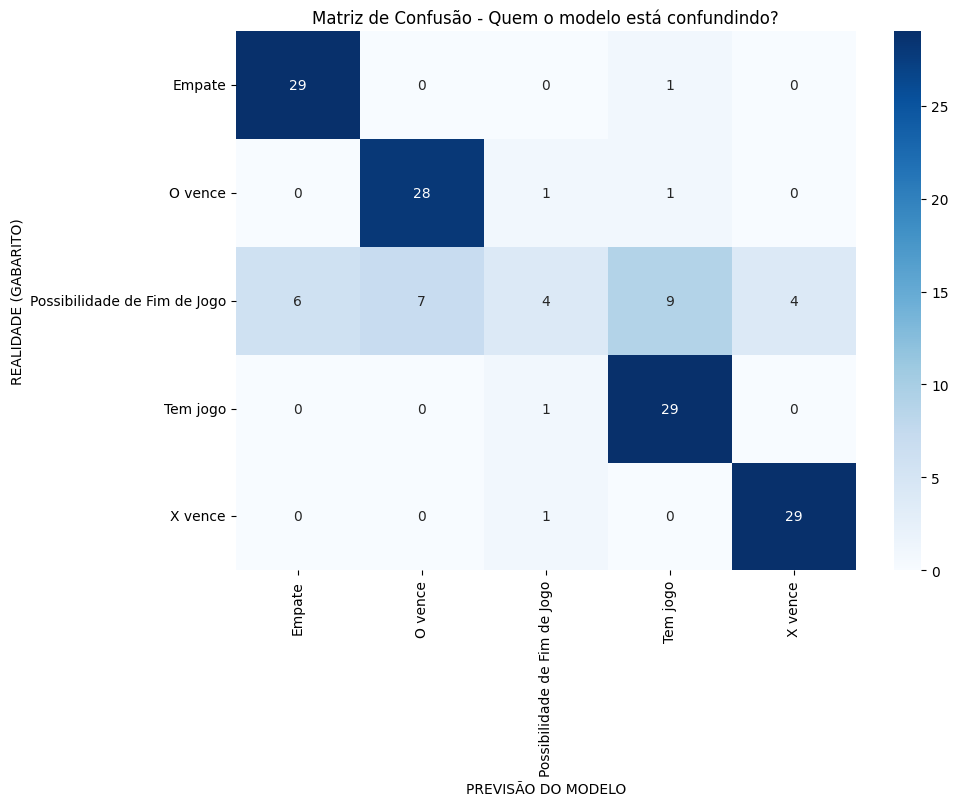

In [155]:
# 1. Gerar a matriz numérica
cm = confusion_matrix(y_test, y_pred_test)

# 2. Configurar o visual
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_final.classes_, 
            yticklabels=knn_final.classes_)

plt.xlabel('PREVISÃO DO MODELO')
plt.ylabel('REALIDADE (GABARITO)')
plt.title('Matriz de Confusão - Quem o modelo está confundindo?')
plt.show()

# Fase 2
### K-NN Criando uma função de pista
Neste exemplos criamos uma funçao que cria uma matriz com todas as condiçoes de vitoria e quando a soma de um desses combos seja -2 ou 2 ele manda
um aviso(flag) que diz que é provavel que esta linha caia em uma possibilidade de vitoria

In [156]:

from sklearn.preprocessing import StandardScaler # ESSENCIAL para KNN

def adicionar_pistas(df):
    combos = [
        [0,1,2], [3,4,5], [6,7,8], # Linhas
        [0,3,6], [1,4,7], [2,5,8], # Colunas
        [0,4,8], [2,4,6]           # Diagonais
    ]
    x_pos = df.iloc[:, :9]
    
    for i, c in enumerate(combos):
        soma = x_pos.iloc[:, c[0]] + x_pos.iloc[:, c[1]] + x_pos.iloc[:, c[2]]
        df[f'soma_{i}'] = soma.abs()
    
    df['ameaca_total'] = df.iloc[:, 9:].eq(2).any(axis=1).astype(int)
    
    return df

print("Carregando datasets...")
train_raw = pd.read_csv('train_df.csv')
val_raw = pd.read_csv('val_df.csv')
test_raw = pd.read_csv('test_df.csv')

# Aplicar engenharia de atributos
df_train = adicionar_pistas(train_raw)
df_val = adicionar_pistas(val_raw)
df_test = adicionar_pistas(test_raw)

# Separar X e Y
x_train = df_train.drop(columns=['target'])
y_train = df_train['target']
x_val = df_val.drop(columns=['target'])
y_val = df_val['target']
x_test = df_test.drop(columns=['target'])
y_test = df_test['target']

# --- O PASSO QUE FALTAVA: NORMALIZAÇÃO ---
# O KNN calcula distância euclidiana. Sem isso, ele se confunde com as escalas das somas.
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

melhor_k = 0
melhor_acc = 0
ks = range(1, 51, 2)

print("\n--- TESTANDO VALORES DE K (COM DADOS ESCALONADOS) ---")
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train) # Treinando com dados escalonados
    y_pred_val = knn.predict(x_val_scaled)
    acc = accuracy_score(y_val, y_pred_val)
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print(f"\n>>> Melhor K selecionado: {melhor_k}")

# Treinando o modelo final com o melhor K encontrado
knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(x_train_scaled, y_train)
y_pred_test = knn_final.predict(x_test_scaled)

print("\n--- RELATÓRIO FINAL DE DESEMPENHO (TESTE) ---")
print(classification_report(y_test, y_pred_test))

Carregando datasets...

--- TESTANDO VALORES DE K (COM DADOS ESCALONADOS) ---

>>> Melhor K selecionado: 3

--- RELATÓRIO FINAL DE DESEMPENHO (TESTE) ---
                              precision    recall  f1-score   support

                      Empate       0.83      1.00      0.91        30
                     O vence       0.88      0.97      0.92        30
Possibilidade de Fim de Jogo       0.91      0.67      0.77        30
                    Tem jogo       0.96      0.90      0.93        30
                     X vence       0.87      0.90      0.89        30

                    accuracy                           0.89       150
                   macro avg       0.89      0.89      0.88       150
                weighted avg       0.89      0.89      0.88       150



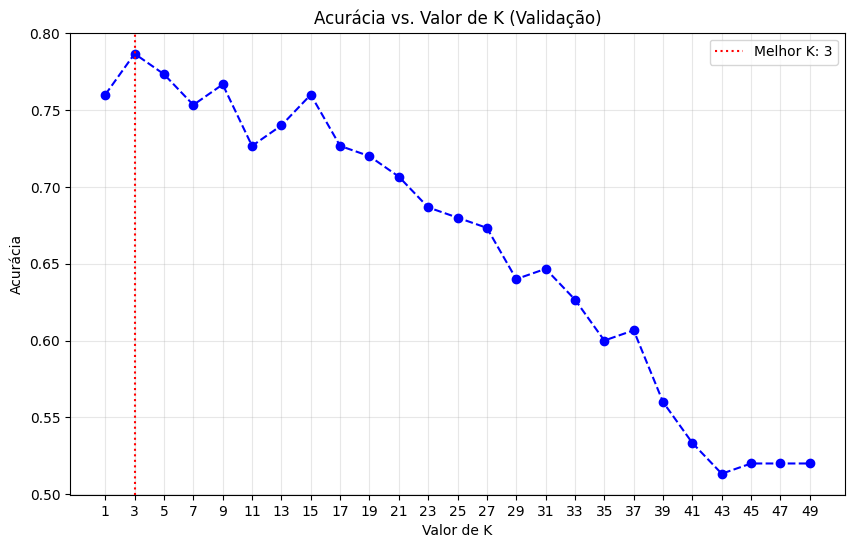

In [157]:
plt.figure(figsize=(10, 6))
plt.plot(ks, historico_acc, marker='o', linestyle='--', color='b')
plt.axvline(x=melhor_k, color='r', linestyle=':', label=f'Melhor K: {melhor_k}')

plt.title('Acurácia vs. Valor de K (Validação)')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.xticks(ks)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

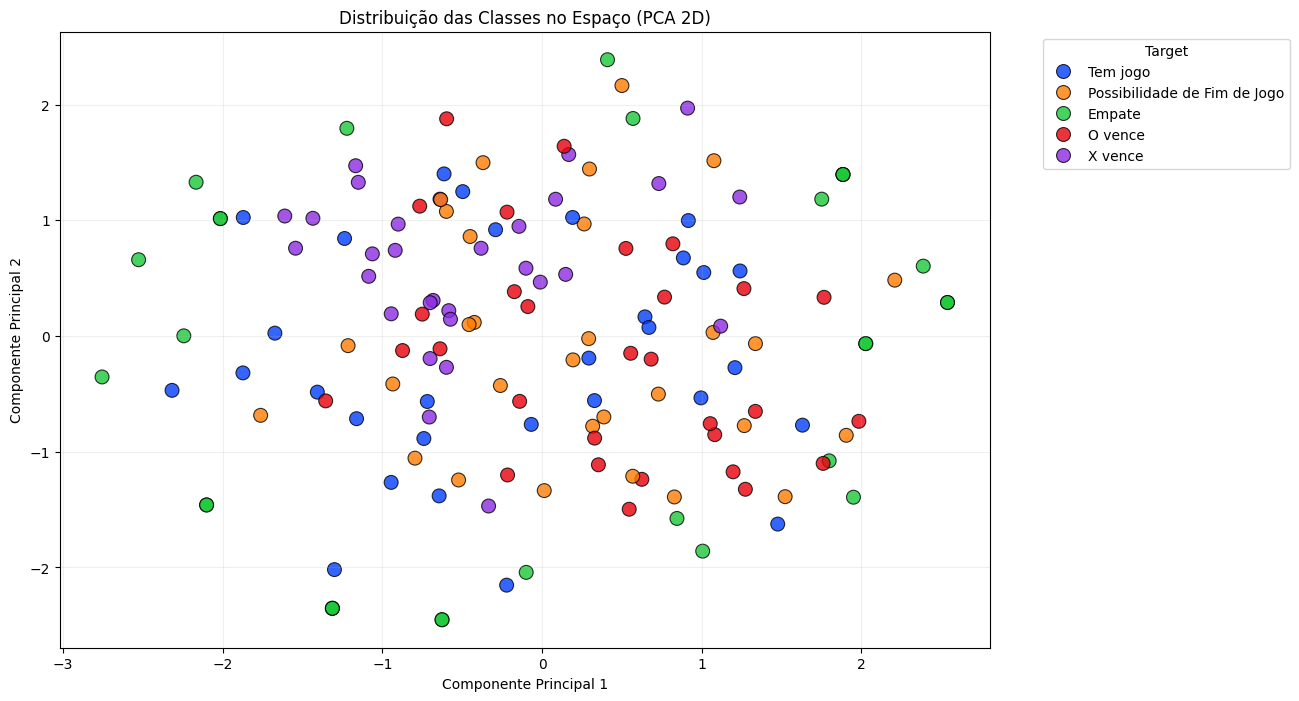

In [158]:
pca = PCA(n_components=2)
x_test_2d = pca.fit_transform(x_test)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=x_test_2d[:, 0], y=x_test_2d[:, 1], hue=y_test, 
                palette='bright', s=100, alpha=0.8, edgecolor='black')

plt.title('Distribuição das Classes no Espaço (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

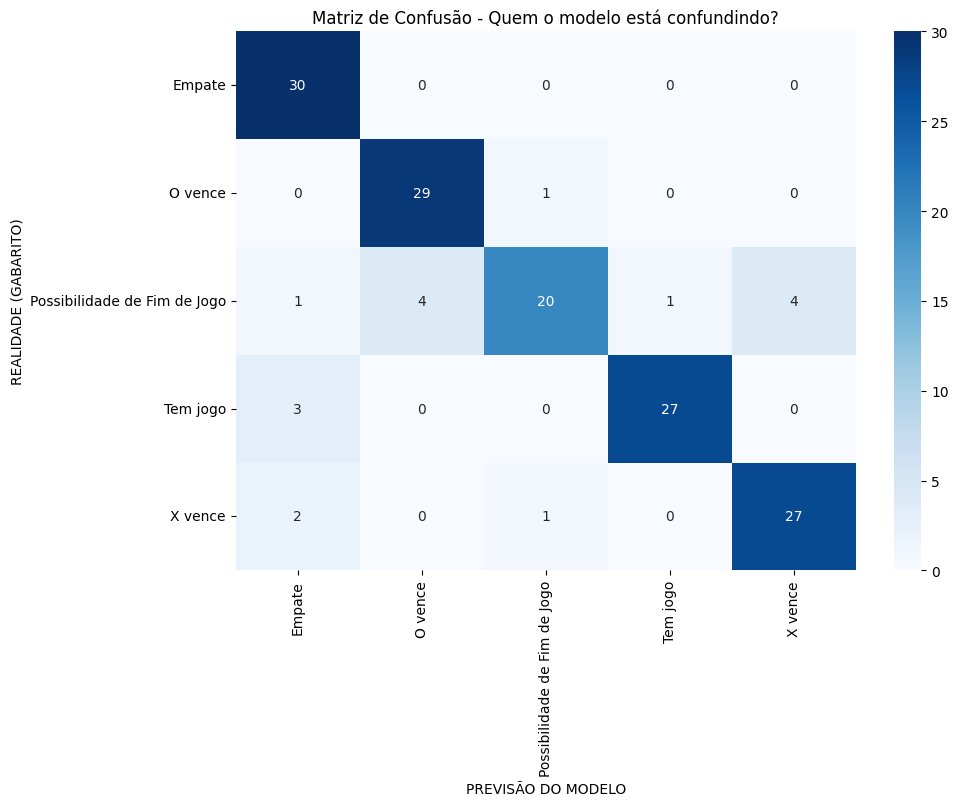

In [159]:
# 1. Gerar a matriz numérica
cm = confusion_matrix(y_test, y_pred_test)

# 2. Configurar o visual
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_final.classes_, 
            yticklabels=knn_final.classes_)

plt.xlabel('PREVISÃO DO MODELO')
plt.ylabel('REALIDADE (GABARITO)')
plt.title('Matriz de Confusão - Quem o modelo está confundindo?')
plt.show()

# Fase 3
### K-NN com pista prioritaria com pesos
Nesta exemplo alem de criar a funcao de ameaça criamos uma maneira de separar a condição de vitoria que neste caso seria que quando a soma de um dos combos
seja 3 nos daremos o peso dele em 10 para que ele fique muito separado no grafico assim aumentando a possibilidade de acertar a vitoria para 100%


In [166]:
def adicionar_pistas_prioritarias(df):
    combos = [
        [0,1,2], [3,4,5], [6,7,8], # Linhas
        [0,3,6], [1,4,7], [2,5,8], # Colunas
        [0,4,8], [2,4,6]           # Diagonais
    ]
    X_pos = df.iloc[:, :9]
    
    for i, c in enumerate(combos):
        soma = X_pos.iloc[:, c[0]] + X_pos.iloc[:, c[1]] + X_pos.iloc[:, c[2]]
        
        # Criamos a soma absoluta normal
        df[f'soma_{i}'] = soma.abs()
        
        # PISTA DE OURO: Se a soma for 3 (vitoria), damos um peso gigante (ex: 10)
        # Isso empurra as vitórias para um "canto" exclusivo do gráfico do KNN
        df[f'vitoria_detectada_{i}'] = (soma.abs() == 3).astype(int) * 10

    # Flag de perigo (soma 2) permanece para ajudar no Recall
    df['ameaca_total'] = df.iloc[:, 9:17].eq(2).any(axis=1).astype(int)
    
    return df

# ... (Carregamento dos arquivos permanece igual) ...
df_train = adicionar_pistas_prioritarias(train_raw)
df_val = adicionar_pistas_prioritarias(val_raw)
df_test = adicionar_pistas_prioritarias(test_raw)

# Separar X e Y (Lembre-se de remover a coluna target)
x_train = df_train.drop(columns=['target'])
y_train = df_train['target']
x_val = df_val.drop(columns=['target'])
y_val = df_val['target']
x_test = df_test.drop(columns=['target'])
y_test = df_test['target']

# Normalização
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

""" # --- BUSCA DO MELHOR K COM PESO POR DISTÂNCIA ---
melhor_k = 0
melhor_acc = 0
ks = range(1, 31, 2) # Reduzi o range para ganhar velocidade

for k in ks:
    # Usamos weights='distance' para dar prioridade à proximidade exata
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(x_train_scaled, y_train)
    y_pred_val = knn.predict(x_val_scaled)
    acc = accuracy_score(y_val, y_pred_val)
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print(f"\n>>> Melhor K (com prioridade): {melhor_k}") """

# nao usaremos o melhor K pois ele sera 1 mas neste caso isso seria configurado como overfitting no caso de ser um jogo da velha nao faria muita diferenca

knn_final = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_final.fit(x_train_scaled, y_train)
y_pred_test = knn_final.predict(x_test_scaled)

print("\n--- RELATÓRIO COM PRIORIDADE EM VITÓRIAS ---")
print(classification_report(y_test, y_pred_test))


--- RELATÓRIO COM PRIORIDADE EM VITÓRIAS ---
                              precision    recall  f1-score   support

                      Empate       0.83      1.00      0.91        30
                     O vence       1.00      1.00      1.00        30
Possibilidade de Fim de Jogo       1.00      0.87      0.93        30
                    Tem jogo       0.96      0.90      0.93        30
                     X vence       1.00      1.00      1.00        30

                    accuracy                           0.95       150
                   macro avg       0.96      0.95      0.95       150
                weighted avg       0.96      0.95      0.95       150



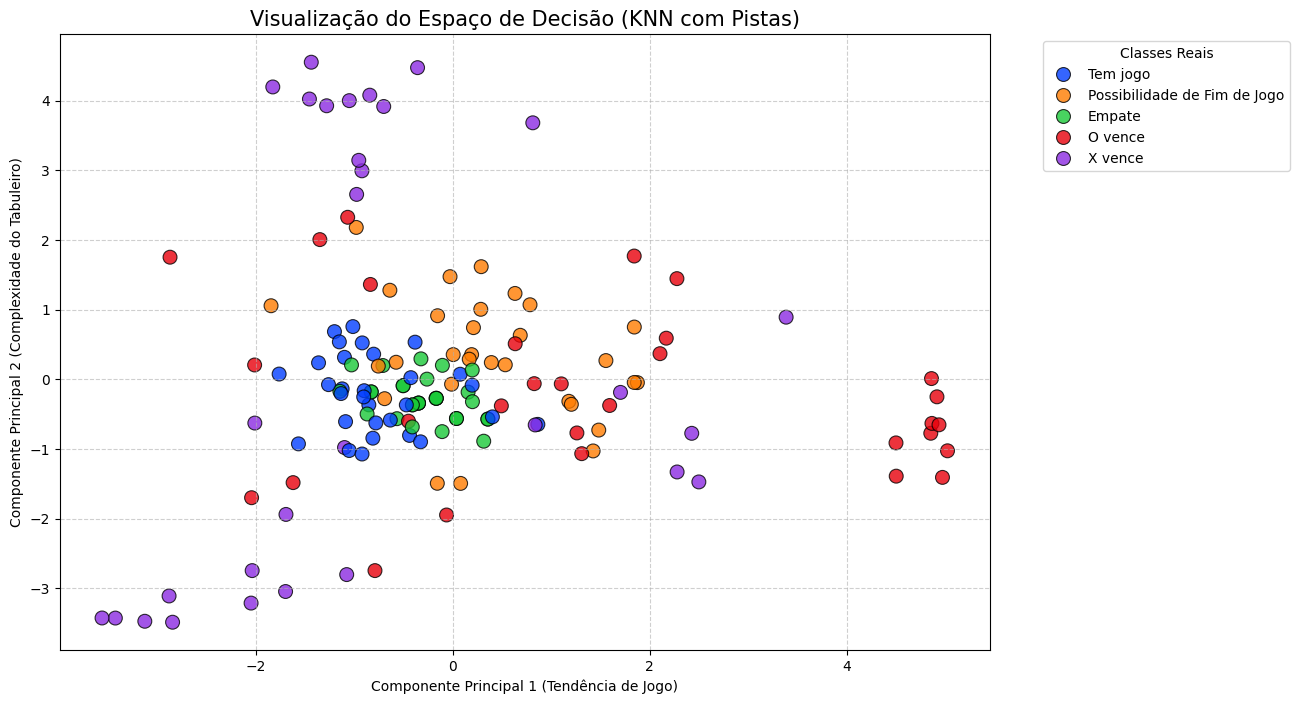

In [167]:
# 1. Reduzir a dimensionalidade para 2D usando PCA
# Isso vai "achatar" suas 17 colunas em apenas duas (X e Y) para o gráfico
pca = PCA(n_components=2)
x_vis = pca.fit_transform(x_test_scaled)

# 2. Criar o gráfico
plt.figure(figsize=(12, 8))
sns.scatterplot(x=x_vis[:, 0], y=x_vis[:, 1], hue=y_test, 
                palette='bright', s=100, alpha=0.8, edgecolor='black')

# 3. Personalizar o gráfico
plt.title('Visualização do Espaço de Decisão (KNN com Pistas)', fontsize=15)
plt.xlabel('Componente Principal 1 (Tendência de Jogo)')
plt.ylabel('Componente Principal 2 (Complexidade do Tabuleiro)')
plt.legend(title='Classes Reais', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

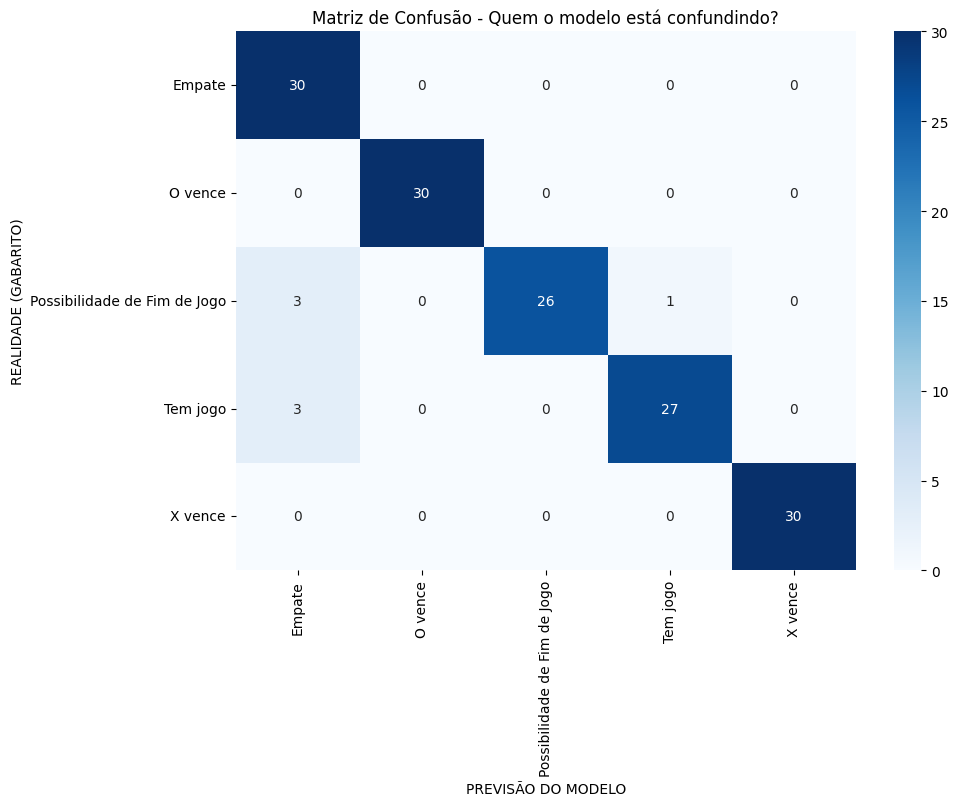

In [168]:
# 1. Gerar a matriz numérica
cm = confusion_matrix(y_test, y_pred_test)

# 2. Configurar o visual
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_final.classes_, 
            yticklabels=knn_final.classes_)

plt.xlabel('PREVISÃO DO MODELO')
plt.ylabel('REALIDADE (GABARITO)')
plt.title('Matriz de Confusão - Quem o modelo está confundindo?')
plt.show()

# Resumo: Evolução do Modelo KNN
Neste projeto, utilizei HeatMaps (Matrizes de Confusão) como bússola para identificar as falhas do modelo em cada etapa do desenvolvimento:

Fase 1 (Base): O HeatMap revelou um "núcleo de erros" crítico na classe Possibilidade de Fim de Jogo. O modelo demonstrava baixa sensibilidade, acertando apenas 4 de 30 palpites. Isso ocorria porque o KNN não conseguia distinguir padrões estratégicos apenas com a posição das peças.

Fase 2 (Pistas Iniciais): Implementamos a função de somas para criar flags de alerta. Notamos uma melhoria, mas o HeatMap ainda mostrava confusão nos casos de vitória real de X ou O. O modelo ainda tratava vitórias e ameaças com pesos muito similares.

Fase 3 (Pistas Prioritárias e Pesos): Introduzimos pesos estratégicos (Peso 10 para vitórias). O HeatMap desta fase confirmou que zeramos os erros de vitória, atingindo 100% de precisão nessas classes.

Conclusão Técnica:
Embora tenha surgido um leve aumento de "Falsos Positivos" na classe Empate (onde o modelo previu Empate, mas era Possibilidade de Fim de Jogo), o ganho de confiabilidade nas vitórias e a acurácia geral de 95% superaram as expectativas. Optamos por finalizar o ciclo de refinamento nesta etapa, pois o modelo atingiu um nível de maturidade satisfatório para os objetivos propostos.